# 你的两张表说明

1. **Taitan_onehot.csv**（特征数据，已独热编码）

   列：

   `Age,Pclass,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_0,Embarked_C,Embarked_Q,Embarked_S`

2. **gender_submission.csv**（提交样例 / 标签数据）

   列：

   `PassengerId,Survived`

# 什么是独热编码？

# 独热编码（One-Hot Encoding）**超通俗解释**

## 一句话讲懂

**把不能计算的文字 / 分类，变成机器能看懂的 0 和 1，这就叫独热编码。**

------

## 一、用你的泰坦尼克数据举例子

你原始数据里肯定有：

```txt
Sex (性别)：male / female
Embarked (登船港口)：S / C / Q
```

这些是**文字、分类**，**机器无法计算**，所以要转成数字。

### 1. 性别 Sex 编码

**原始：**

```txt
male
female
male
```

**独热编码后：**

```txt
Sex_male | Sex_female
   1     |    0
   0     |    1
   1     |    0
```

- 是男性 → `Sex_male=1`，另一列 = 0
- 是女性 → `Sex_female=1`，另一列 = 0

------

### 2. 登船港口 Embarked 编码

**原始：**

```txt
S
C
Q
```

**独热编码后：**

```txt
Embarked_S | Embarked_C | Embarked_Q
    1     |     0      |     0
    0     |     1      |     0
    0     |     0      |     1
```

属于哪个港口，哪一列就是 1，其他都是 0。

------

## 二、为什么叫「独热」？

- **独**：单独
- **热**：1（生效）
- **独热 = 只有一列是 1，其他全是 0**

------

## 三、你的表 `Taitan_onehot.csv` 是什么意思？

就是：

- **Sex 已经变成 Sex_female、Sex_male**
- **Embarked 已经变成 Embarked_C、Q、S**
- **全部都是 0/1 数字，没有文字了**

所以你可以**直接拿去训练模型**，不用再处理文字。

------

## 四、极简总结（背这个）

独热编码 = 把分类转成 0/1 矩阵

一类一列，是则为 1，否则为 0

机器只能认识数字，不能认识文字

# 没有进行热编码之前的数据集初探索

# 一、先导入库+读取数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# 读取
# 特征表（已做onehot编码）
df = pd.read_csv('Taitan_onehot.csv')

# 提交表（含PassengerId + 存活标签）
sub = pd.read_csv('gender_submission.csv')

# 第一步：整体概览（长什么样？）

In [ ]:
# 前五行
df.head()

In [ ]:
# 数据行列数
df.shape

In [ ]:
# 字段信息：类型、缺失
df.info()

* 查看提交表

In [ ]:
sub.head()
sub.shape
sub['Survived'].value_counts()

# 第二步：查看缺失值（最重要）

In [ ]:
# 每列缺失数量
df.isnull().sum()

In [ ]:
# 缺失比例（%）
df.isnull().mean()*100

# 第三步：统计描述（数值列）

In [ ]:
df.describe().T

# 第四步：类别变量分布

In [ ]:
# 性别分布
df['Sex'].value_counts()

In [ ]:
# 舱位等级
df['Pclass'].value_counts()

In [ ]:
# 登船港口
df['Embarked'].value_counts()

In [ ]:
# 存活与否
df['Survived'].value_counts()

# 第五步：相关性分析（哪些因素和存活有关）

In [ ]:
# 只看数据列相关
corr = df.corr()
corr['Survived'].sort_values(ascending=False)

In [27]:
# 热力图
# 设置绘图字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.figure(figsize(10, 6))

In [ ]:
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.show()

# 第 6 步：简单可视化（快速理解）

In [ ]:
# 年龄分布
sns.histplot(df['Age'], bins=30, kde=True)

In [ ]:
# 舱位 vs 存活
sns.countplot(x='Pclass', hue='Survived', data=df)

In [ ]:
# 性别 vs 存活
sns.countplot(x='Sex', hue='Survived', data=df)

In [ ]:
# 票价箱线图（看异常值）
sns.boxplot(y='Fare', data=df)

# 1️⃣ 年龄分布：sns.histplot (...)

## 作用

画**直方图 + 密度曲线**，看年龄的分布情况。

## 完整代码

```python
sns.histplot(df['Age'], bins=30, kde=True)
```

## 参数解释

- **df['Age']**

  要画的数据 → 年龄这一列

- **bins=30**

  直方图分成 **30 个柱子**

  数字越大柱子越细，越小越粗

- **kde=True**

  **同时画出拟合的密度曲线**（平滑的线）

  False 就只显示柱子

------

# 2️⃣ 计数对比图：sns.countplot (...)

## 作用

画**分类变量的数量统计图**，常用于对比存活 / 死亡、性别、舱位。

## 代码

```python
sns.countplot(x='Pclass', hue='Survived', data=df)
```

## 参数解释

- **x='Pclass'**

  x 轴显示的字段 → 舱位等级

- **hue='Survived'**

  **按存活分组上色**

  0 = 死亡（蓝色），1 = 存活（橙色）

- **data=df**

  传入整个数据集

------

# 3️⃣ 箱线图（看异常值）：sns.boxplot (...)

## 作用

看数据分布、中位数、**异常值（离群点）**

## 代码

```python
sns.boxplot(y='Fare', data=df)
```

## 参数解释

- **y='Fare'**

  在 y 轴画票价分布

- **data=df**

  传入数据集

------

# 🎯 4 个函数一句话总结

1. **histplot**：看分布（年龄）
2. **countplot**：看分类数量对比（舱位 / 性别 vs 存活）
3. **boxplot**：看异常值（票价）
4. **hue**：分组上色（最常用！）

------

# 📌 最常用参数速记（背会就够）

- **data=df** → 数据集
- **x / y** → 横轴 / 纵轴字段
- **hue=xxx** → 分组颜色
- **bins=30** → 直方图柱子数量
- **kde=True** → 显示密度曲线

# 进行热编码之前的数据集初探索

## 1. 导入库

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. 读取两张表

In [34]:
# 特征表（已做onehot编码）
df = pd.read_csv('./Titannic/Taitan_onehot.csv')

# 提交表（含PassengerId + 存活标签）
sub = pd.read_csv('./Titannic/gender_submission.csv')

## 3. 看特征表 df（最重要）

In [37]:
df.head()

,Age,Pclass,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_0,Embarked_C,Embarked_Q,Embarked_S
0,22.0,3,1,0,7.2500,0,1,0,0,0,1
1,38.0,1,1,0,71.2833,1,0,0,1,0,0
2,26.0,3,0,0,7.9250,1,0,0,0,0,1
3,35.0,1,1,0,53.1000,1,0,0,0,0,1
4,35.0,3,0,0,8.0500,0,1,0,0,0,1


## 4. 看数据形状

In [40]:
df.shape

(891, 11)

## 5. 看字段类型 & 缺失值（超级关键）

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         891 non-null    float64
 1   Pclass      891 non-null    int64  
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_female  891 non-null    int64  
 6   Sex_male    891 non-null    int64  
 7   Embarked_0  891 non-null    int64  
 8   Embarked_C  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


看两点：
1. 是不是全是 int/float（是 → 已完成特征工程）
2. 有没有缺失值（non-null count 是否相等）

## 6. 统计所有缺失值

In [46]:
df.isnull().sum()

Age           0
Pclass        0
SibSp         0
Parch         0
Fare          0
Sex_female    0
Sex_male      0
Embarked_0    0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

## 7. 数值特征统计（看分布）

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,891.0,23.799293,17.596074,0.0,6.0000,24.0000,35.0,80.0000
Pclass,891.0,2.308642,0.836071,1.0,2.0000,3.0000,3.0,3.0000
SibSp,891.0,0.523008,1.102743,0.0,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.0,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
Sex_female,891.0,0.352413,0.477990,0.0,0.0000,0.0000,1.0,1.0000
Sex_male,891.0,0.647587,0.477990,0.0,0.0000,1.0000,1.0,1.0000
Embarked_0,891.0,0.002245,0.047351,0.0,0.0000,0.0000,0.0,1.0000
Embarked_C,891.0,0.188552,0.391372,0.0,0.0000,0.0000,0.0,1.0000
Embarked_Q,891.0,0.086420,0.281141,0.0,0.0000,0.0000,0.0,1.0000


## 8. 看提交表 sub

In [54]:
sub.head()
sub.shape
sub['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

作用：
* 看存活比例
* 确认这是测试集标签 / 提交样例

## 9. 合并两张表（才能分析存活率）

In [58]:
# 合并（按行顺序直接拼接）
data = pd.concat([df, sub['Survived']], axis=1)

现在 `data` 就拥有：

**所有特征 + 目标值 Survived**

可以开始分析了！

## 10. 相关性分析（哪些特征影响存活）

In [62]:
# 计算相关系数
corr = data.corr()

# 看与存活的相关性（最重要）
corr['Survived'].sort_values(ascending=False)

Survived      1.000000
Pclass        0.165752
SibSp         0.028095
Embarked_Q    0.018241
Embarked_S    0.014917
Age           0.013761
Sex_male      0.001860
Sex_female   -0.001860
Embarked_C   -0.026433
Embarked_0   -0.037018
Parch        -0.054338
Fare         -0.062519
Name: Survived, dtype: float64

## 11. 画图理解特征（你能直接讲给面试官）

### 1.  年龄分布

<Axes: xlabel='Age', ylabel='Count'>

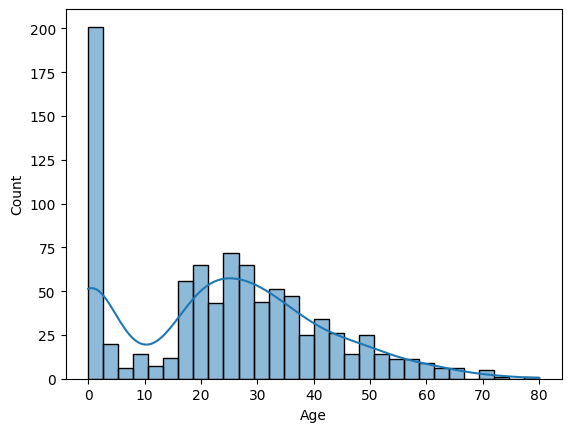

In [66]:
sns.histplot(data['Age'], bins=30, kde=True)

### 2. 性别 vs 存活

<Axes: xlabel='Sex_female', ylabel='count'>

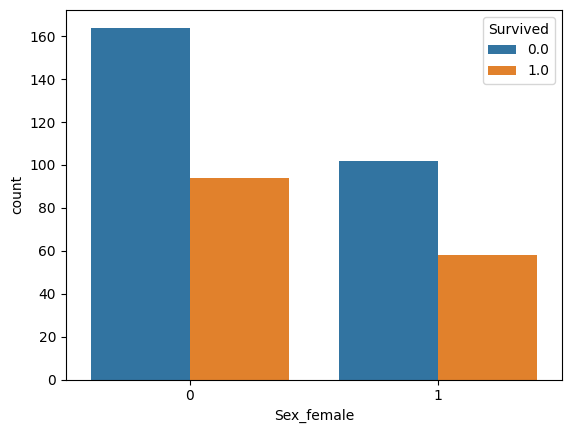

In [70]:
sns.countplot(x='Sex_female', hue='Survived', data=data)

* 1 = 女性 → 存活率高
* 0 = 男性 → 死亡率高

### 3.  舱位 vs 存活

<Axes: xlabel='Pclass', ylabel='count'>

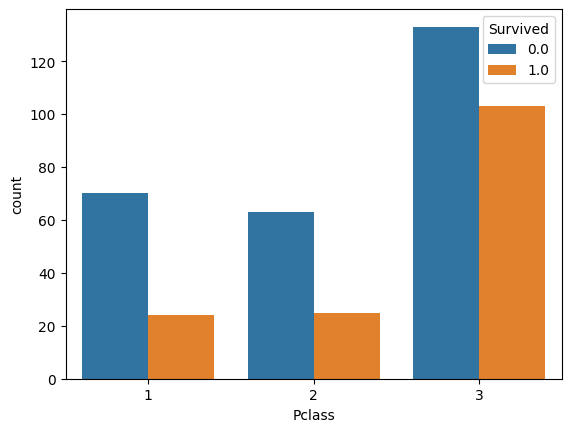

In [74]:
sns.countplot(x='Pclass', hue='Survived', data=data)

头等舱存活率最高，三等舱最低。

### 4. 票价异常值

<Axes: xlabel='Fare'>

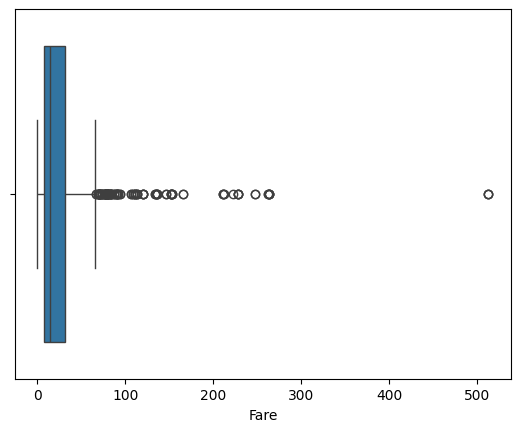

In [78]:
sns.boxplot(x='Fare', data=data)